# Credix — Análise Exploratória de Dados (EDA)

Objetivo: entender a base **Home Credit Default Risk** e justificar as colunas
selecionadas pelo pipeline (`DataPipeline/01_application_features.py` +
`02_bureau_features.py`).

Fontes usadas neste projeto: `application_train.csv` (dados cadastrais/financeiros) +
`bureau.csv` (histórico de crédito).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

app = pd.read_csv("../Dados/raw_data/application_train.csv")
bureau = pd.read_csv("../Dados/raw_data/bureau.csv")
print("application_train:", app.shape)
print("bureau:", bureau.shape)

application_train: (307511, 122)
bureau: (1716428, 17)


## 1. Visão geral da base

In [2]:
app.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,...,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.028663,-19932,-3038,-4311.0,-3458,NaN,1,1,0,...,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
app.dtypes.value_counts()

float64    65
int64      41
str        16
Name: count, dtype: int64

## 2. Distribuição da variável alvo (`TARGET`)

Problema de **classificação binária desbalanceada**: a maioria dos clientes paga em dia.

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


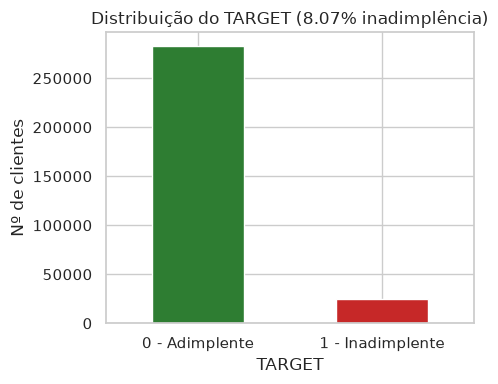

In [4]:
target_counts = app["TARGET"].value_counts(normalize=True) * 100
print(target_counts)

fig, ax = plt.subplots(figsize=(5, 4))
app["TARGET"].value_counts().plot(kind="bar", color=["#2e7d32", "#c62828"], ax=ax)
ax.set_xticklabels(["0 - Adimplente", "1 - Inadimplente"], rotation=0)
ax.set_title(f"Distribuição do TARGET ({target_counts[1]:.2f}% inadimplência)")
ax.set_ylabel("Nº de clientes")
plt.tight_layout()
plt.show()

## 3. Valores ausentes

Visão geral de nulos na base bruta — justifica por que o pipeline seleciona só um
subconjunto de colunas (as com maior completude e relevância de negócio).

In [5]:
null_pct = (app.isnull().mean() * 100).sort_values(ascending=False)
print(f"Colunas com >40% de nulos: {(null_pct > 40).sum()} de {app.shape[1]}")
null_pct.head(15)

Colunas com >40% de nulos: 49 de 122


COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
FLOORSMIN_MODE              67.848630
FLOORSMIN_AVG               67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_AVG             66.497784
YEARS_BUILD_MODE            66.497784
dtype: float64

## 4. Colunas selecionadas pelo pipeline

O pipeline (`01_application_features.py`) usa um subconjunto pequeno e de baixa
ausência de nulos: `AMT_INCOME_TOTAL`, `AMT_CREDIT`, `AMT_ANNUITY`, `AMT_GOODS_PRICE`,
`DAYS_BIRTH`, `DAYS_EMPLOYED`, `NAME_EDUCATION_TYPE`, `NAME_FAMILY_STATUS` — todas com
baixíssima taxa de nulos e relação direta com capacidade de pagamento.

In [6]:
cols_pipeline = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE",
                 "DAYS_BIRTH", "DAYS_EMPLOYED", "NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS"]
null_pct[cols_pipeline]

AMT_INCOME_TOTAL       0.000000
AMT_CREDIT             0.000000
AMT_ANNUITY            0.003902
AMT_GOODS_PRICE        0.090403
DAYS_BIRTH             0.000000
DAYS_EMPLOYED          0.000000
NAME_EDUCATION_TYPE    0.000000
NAME_FAMILY_STATUS     0.000000
dtype: float64

## 5. Anomalia em `DAYS_EMPLOYED`

Valor sentinela `365243` (~1000 anos) usado para representar "não empregado" —
tratado no pipeline como nulo antes de calcular `TEMPO_EMPRESA`.

Registros com DAYS_EMPLOYED == 365243 (anômalo): 55374 (18.01% da base)


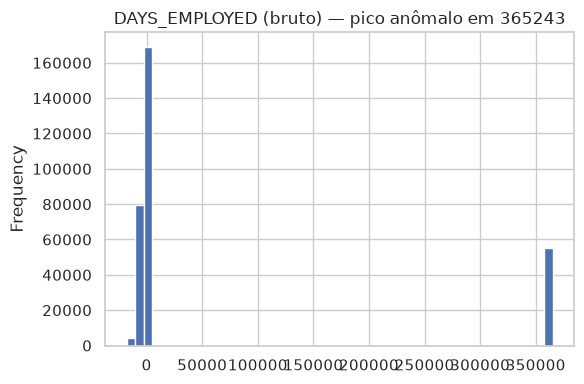

In [7]:
anomalia = (app["DAYS_EMPLOYED"] == 365243).sum()
print(f"Registros com DAYS_EMPLOYED == 365243 (anômalo): {anomalia} "
      f"({100*anomalia/len(app):.2f}% da base)")

fig, ax = plt.subplots(figsize=(6, 4))
app["DAYS_EMPLOYED"].plot(kind="hist", bins=50, ax=ax)
ax.set_title("DAYS_EMPLOYED (bruto) — pico anômalo em 365243")
plt.tight_layout()
plt.show()

## 6. Variáveis financeiras × TARGET

Renda, valor do crédito, valor da parcela e valor do bem — checando separação entre
adimplentes e inadimplentes (justifica o uso dessas variáveis e das razões derivadas
`CREDITO_RENDA`, `PARCELA_RENDA`, `BEM_RENDA` calculadas no pipeline).

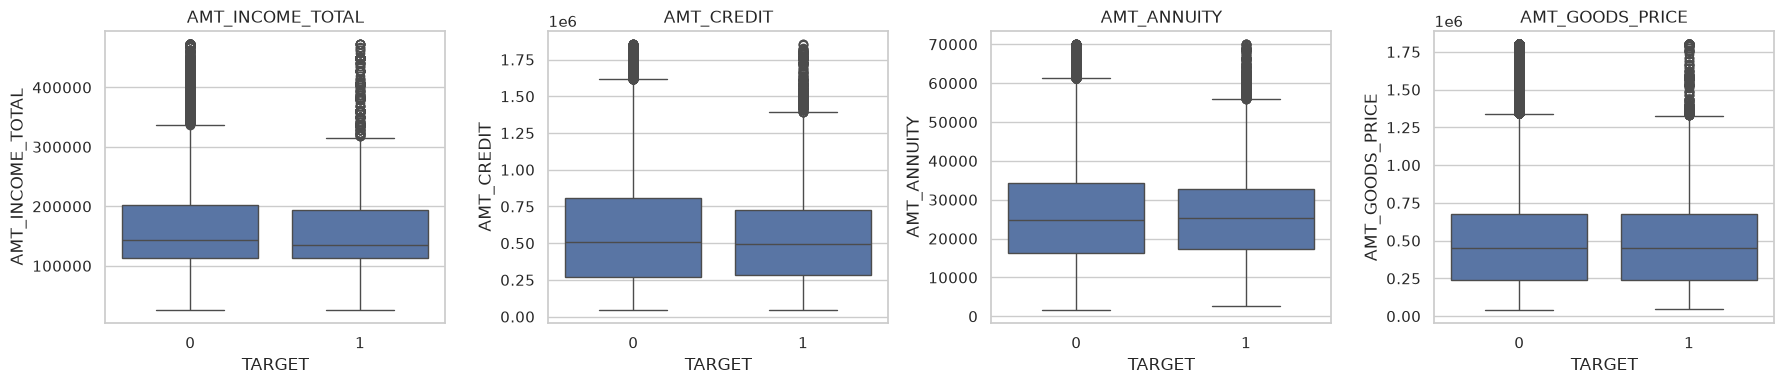

In [8]:
fin_cols = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, fin_cols):
    data = app[[col, "TARGET"]].dropna()
    # recorta outliers extremos (percentil 99) só para visualização
    p99 = data[col].quantile(0.99)
    sns.boxplot(data=data[data[col] <= p99], x="TARGET", y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 7. Idade e tempo de empresa × TARGET

Clientes mais jovens e com menos tempo de casa tendem a ter mais risco — padrão
conhecido em crédito (menor histórico, menor estabilidade).

/tmp/ipykernel_9606/3776786307.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app["IDADE"] = abs(app["DAYS_BIRTH"]) / 365
/tmp/ipykernel_9606/3776786307.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app["TEMPO_EMPRESA"] = (abs(tempo_emp) / 365).fillna(0)


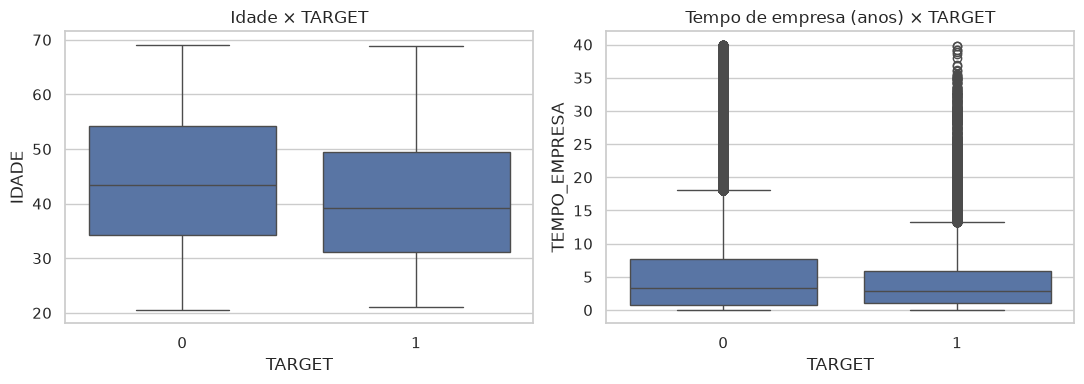

            IDADE  TEMPO_EMPRESA
TARGET                          
0       44.214182       5.442008
1       40.780351       4.373491


In [9]:
app["IDADE"] = abs(app["DAYS_BIRTH"]) / 365
tempo_emp = app["DAYS_EMPLOYED"].replace(365243, np.nan)
app["TEMPO_EMPRESA"] = (abs(tempo_emp) / 365).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=app, x="TARGET", y="IDADE", ax=axes[0])
axes[0].set_title("Idade × TARGET")
sns.boxplot(data=app[app["TEMPO_EMPRESA"] <= 40], x="TARGET", y="TEMPO_EMPRESA", ax=axes[1])
axes[1].set_title("Tempo de empresa (anos) × TARGET")
plt.tight_layout()
plt.show()

print(app.groupby("TARGET")[["IDADE", "TEMPO_EMPRESA"]].mean())

## 8. Escolaridade e estado civil × TARGET

Taxa de inadimplência por categoria.

In [10]:
for col in ["NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS"]:
    taxa = (app.groupby(col)["TARGET"].mean() * 100).sort_values(ascending=False)
    print(f"\n{col} — taxa de inadimplência (%):")
    print(taxa.round(2))


NAME_EDUCATION_TYPE — taxa de inadimplência (%):
NAME_EDUCATION_TYPE
Lower secondary                  10.93
Secondary / secondary special     8.94
Incomplete higher                 8.48
Higher education                  5.36
Academic degree                   1.83
Name: TARGET, dtype: float64

NAME_FAMILY_STATUS — taxa de inadimplência (%):
NAME_FAMILY_STATUS
Civil marriage          9.94
Single / not married    9.81
Separated               8.19
Married                 7.56
Widow                   5.82
Unknown                 0.00
Name: TARGET, dtype: float64


## 9. Histórico de crédito (`bureau.csv`) × TARGET

Quantidade de créditos, créditos ativos e dívida total registrados no bureau —
agregados por cliente em `02_bureau_features.py`.

In [11]:
bureau_agg = (
    bureau.groupby("SK_ID_CURR")
    .agg(
        BUREAU_QTD_CREDITOS=("SK_ID_BUREAU", "count"),
        BUREAU_TOTAL_DIVIDA=("AMT_CREDIT_SUM_DEBT", "sum"),
    )
    .reset_index()
)
merged = app[["SK_ID_CURR", "TARGET"]].merge(bureau_agg, on="SK_ID_CURR", how="left")
print(merged.groupby("TARGET")[["BUREAU_QTD_CREDITOS", "BUREAU_TOTAL_DIVIDA"]].median())

        BUREAU_QTD_CREDITOS  BUREAU_TOTAL_DIVIDA
TARGET                                          
0                       4.0             162063.0
1                       4.0             256288.5


## 10. Conclusões da EDA

- Base fortemente **desbalanceada** (~8% de inadimplência) → exige `class_weight`/
  `scale_pos_weight` no treino e métricas além de acurácia (AUC, recall, F1).
- `DAYS_EMPLOYED` tem sentinela `365243` que precisa ser tratado como nulo antes de
  qualquer cálculo de tempo de empresa.
- As variáveis financeiras (renda, crédito, parcela, bem) e suas razões derivadas
  mostram separação visível entre as classes — justificam a engenharia de atributos
  feita em `01_application_features.py`.
- Idade, tempo de empresa, escolaridade e estado civil também mostram diferença de
  taxa de inadimplência entre categorias — mantidas no pipeline.
- O histórico do bureau (quantidade de créditos, dívida total) agrega sinal adicional
  sobre o comportamento de crédito do cliente fora da Credix.

Próximo passo: construção da ABT (`merge_abt.py`) e comparação de algoritmos
(`evaluation.ipynb`).